# TMDPDF Band Comparison

Load the stored TMD band `.pkl` files from `TMD bands/` and compare the replica and Bayesian uncertainty bands in `k_T` space.

This notebook is now a pure plotting notebook: it does not evaluate Julia theory or regenerate the bands.


In [1]:
import pickle
import sys
from pathlib import Path
from shutil import which

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display

local_widget_vendor = Path(r"C:\cwlib")
if local_widget_vendor.exists() and str(local_widget_vendor) not in sys.path:
    sys.path.insert(0, str(local_widget_vendor))

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

if which("latex"):
    plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
    plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Helvetica"]})
    plt.rc("text", usetex=True)
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["figure.dpi"] = 120


## Configuration


In [2]:
BASE_CANDIDATES = [
    Path("TMD bands"),
    Path("Replica Analysis") / "TMD bands",
    Path("TMD-Fits-Minimal") / "Replica Analysis" / "TMD bands",
]
for candidate in BASE_CANDIDATES:
    if candidate.exists():
        BAND_BASE = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not find TMD bands/")

plot_flavors = ["u"]
replica_band_names = {
    "u": "replica_tmd_band.pkl",
}
bayesian_band_names = {
    "u": "bayesian_tmd_band.pkl",
}

replica_band_paths = {flavor: (BAND_BASE / replica_band_names[flavor]) for flavor in plot_flavors}
bayesian_band_paths = {flavor: (BAND_BASE / bayesian_band_names[flavor]) for flavor in plot_flavors}
plot_output_path = (Path("Plots_old") / "TMD_bands.pdf").resolve()

for flavor in plot_flavors:
    if not replica_band_paths[flavor].exists():
        raise FileNotFoundError(f"Missing replica band pickle for {flavor}: {replica_band_paths[flavor]}")
    if not bayesian_band_paths[flavor].exists():
        raise FileNotFoundError(f"Missing Bayesian band pickle for {flavor}: {bayesian_band_paths[flavor]}")
plot_output_path.parent.mkdir(parents=True, exist_ok=True)
replica_label = r"$\mathrm{Replica}$"
bayesian_label = r"$\mathrm{Bayesian}$"

sizeOfText = 24
sizeOfTick = 22
legend_subtitle_size = 0.92 * sizeOfText
replica_alpha = 0.65
bayesian_alpha = 0.24
band_line_width = 1.0
replica_color = "#C44E52"
top_y_margin_frac = 0.08
q_color_values = None  # fallback, used when widgets are unavailable
q_color_defaults = ["#2485CF"]
q_color_labels = ["u quark"]

if widgets is not None:
    q_color_pickers = [
        widgets.ColorPicker(description=label, value=color, concise=False)
        for label, color in zip(q_color_labels, q_color_defaults)
    ]
    display(widgets.VBox(q_color_pickers))
else:
    q_color_pickers = None

q_colors = None
flavor_colors = None


## Load Stored Replica And Bayesian Bands


In [3]:
def load_band_payload(path: Path):
    with path.open("rb") as handle:
        return pickle.load(handle)


def normalize_nested_space(space):
    normalized = {}
    for q_key, q_dict in space.items():
        q_value = float(q_key)
        normalized[q_value] = {}
        for x_key, df in q_dict.items():
            normalized[q_value][float(x_key)] = df.copy()
    return normalized


def sorted_numeric_keys(mapping):
    return sorted(float(key) for key in mapping.keys())


replica_payloads = {flavor: load_band_payload(replica_band_paths[flavor]) for flavor in plot_flavors}
bayesian_payloads = {flavor: load_band_payload(bayesian_band_paths[flavor]) for flavor in plot_flavors}

replica_spaces = {flavor: normalize_nested_space(replica_payloads[flavor]["kt_space"]) for flavor in plot_flavors}
bayesian_spaces = {flavor: normalize_nested_space(bayesian_payloads[flavor]["kt_space"]) for flavor in plot_flavors}

reference_flavor = plot_flavors[0]
replica_space = replica_spaces[reference_flavor]
bayesian_space = bayesian_spaces[reference_flavor]

map_Q_values = sorted(set(sorted_numeric_keys(replica_space)) & set(sorted_numeric_keys(bayesian_space)))
if not map_Q_values:
    raise ValueError("Replica and Bayesian pickles do not share any usable Q values")

map_x_values = sorted(
    set(sorted_numeric_keys(replica_space[map_Q_values[0]]))
    & set(sorted_numeric_keys(bayesian_space[map_Q_values[0]]))
)
if not map_x_values:
    raise ValueError("Replica and Bayesian pickles do not share any x values")

for flavor in plot_flavors:
    for Q in map_Q_values:
        replica_x = set(sorted_numeric_keys(replica_spaces[flavor][Q]))
        bayesian_x = set(sorted_numeric_keys(bayesian_spaces[flavor][Q]))
        if replica_x != bayesian_x:
            raise ValueError(f"Replica/Bayesian x grids do not match for flavor={flavor} at Q={Q}")

kt_reference_grid = replica_spaces[reference_flavor][float(map_Q_values[0])][float(map_x_values[0])]["kt"].to_numpy(dtype=float)
if q_color_pickers is not None:
    if len(q_color_pickers) != len(plot_flavors):
        raise ValueError(f"Notebook has {len(q_color_pickers)} color pickers but {len(plot_flavors)} flavors")
    for picker, flavor in zip(q_color_pickers, plot_flavors):
        picker.description = f"{flavor} quark"
    q_color_values = [picker.value for picker in q_color_pickers]
if q_color_values is None:
    q_colors = mpl.cm.viridis(np.linspace(0.15, 0.85, len(map_Q_values)))
else:
    if len(q_color_values) != len(plot_flavors):
        raise ValueError(f"q_color_values must have length {len(plot_flavors)}, got {len(q_color_values)}")
    q_colors = list(q_color_values)

flavor_colors = dict(zip(plot_flavors, q_colors))

summary_rows = []
for flavor in plot_flavors:
    for label, payload in [(replica_label, replica_payloads[flavor]), (bayesian_label, bayesian_payloads[flavor])]:
        summary_rows.append(
            {
                "band": label,
                "fit_name": payload["metadata"].get("fit_name"),
                "flavor": payload["metadata"].get("flavor"),
                "n_replicas": payload["metadata"].get("n_replicas"),
                "band_alpha": payload["metadata"].get("band_alpha"),
                "central_curve_mode": payload["metadata"].get("central_curve_mode"),
                "evaluation_mode": payload["metadata"].get("evaluation_mode"),
            }
        )

print(f"Using TMD bands directory: {BAND_BASE}")
print(f"Q values: {map_Q_values}")
print(f"x values: {map_x_values}")
display(pd.DataFrame(summary_rows))


Using TMD bands directory: C:\Users\congyue zhang\Desktop\OpenCL fitter\TMD-Fits-Minimal\Replica Analysis\TMD bands
Q values: [5.0, 100.0]
x values: [0.001, 0.01, 0.1]


,band,fit_name,flavor,n_replicas,band_alpha,central_curve_mode,evaluation_mode
0,$\mathrm{Replica}$,Final_old,u,80,15.865,card,direct
1,$\mathrm{Bayesian}$,Final_old,u,3000,15.865,card,direct


## Plot `k_T` Bands With `CS_plot`-Style Formatting


Saved figure to C:\Users\congyue zhang\Desktop\OpenCL fitter\TMD-Fits-Minimal\Replica Analysis\Plots_old\TMD_bands.pdf


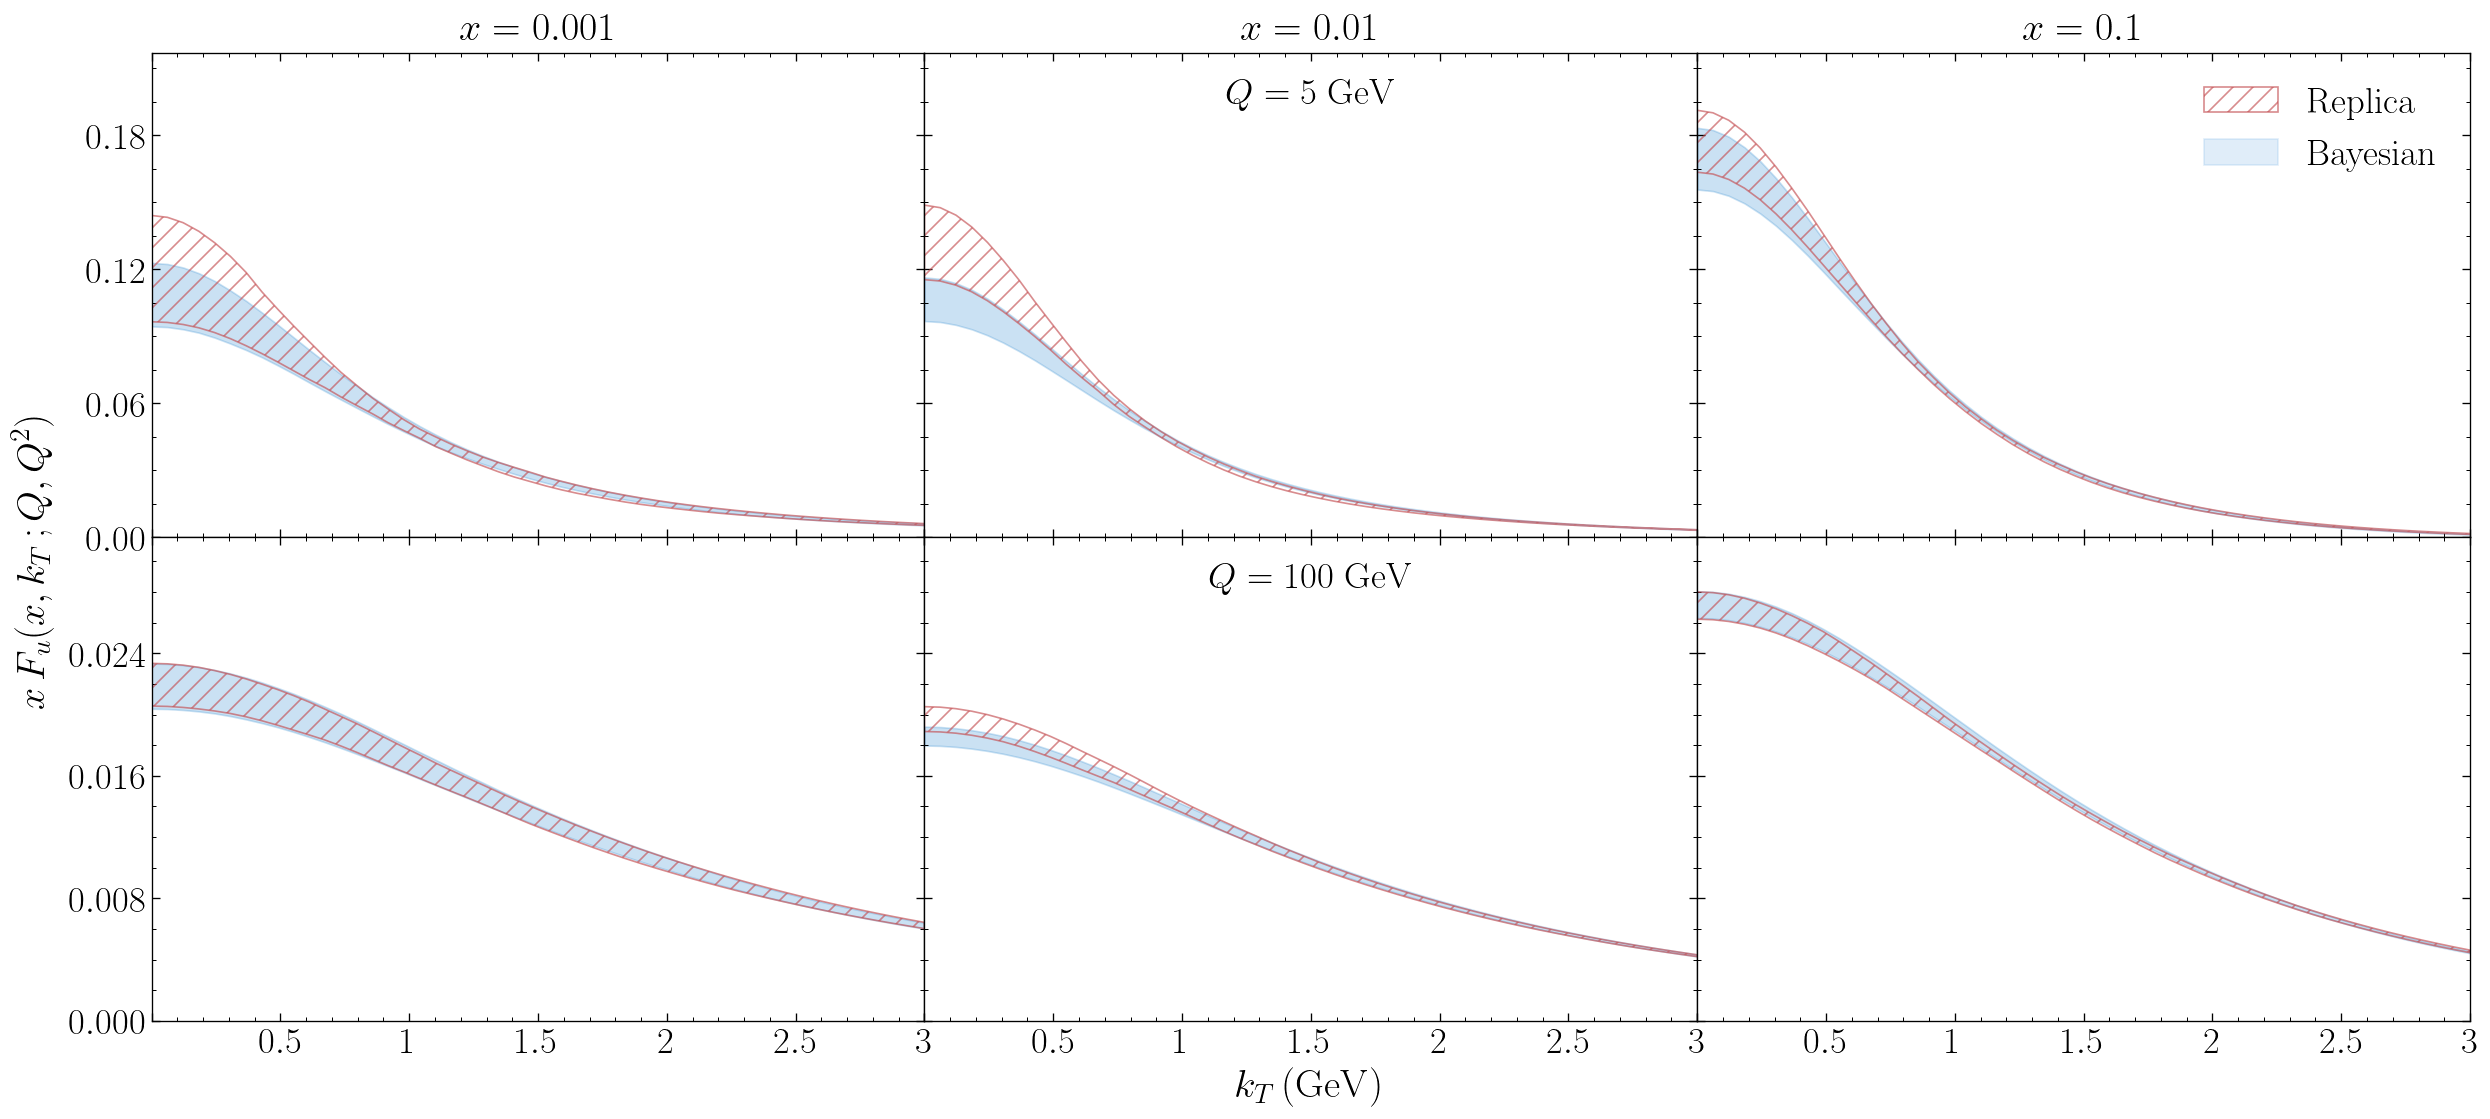

In [4]:
n_rows = len(map_Q_values)
n_cols = len(map_x_values)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.0 * n_cols, 4.8 * n_rows), sharex=True, sharey="row")
axes = np.atleast_2d(axes)
fig.subplots_adjust(left=0.075, right=0.995, bottom=0.10, top=0.94, wspace=0.0, hspace=0.0)

center_axis_index = n_cols // 2
x_min = float(np.min(kt_reference_grid))
x_max = float(np.max(kt_reference_grid))
xtick_step = 0.5
xticks = np.arange(x_min, x_max + 0.5 * xtick_step, xtick_step).tolist()

def make_major_tick_formatter(axis_index, n_axes, ticks):
    def _formatter(value, pos):
        if axis_index > 0 and np.isclose(value, ticks[0]):
            return ""
        if axis_index < n_axes - 1 and np.isclose(value, ticks[-1]):
            return ""
        return rf"$\mathdefault{{{value:g}}}$" if any(np.isclose(value, tick) for tick in ticks) else ""
    return mticker.FuncFormatter(_formatter)

for row_idx, Q in enumerate(map_Q_values):
    for col_idx, x_value in enumerate(map_x_values):
        ax = axes[row_idx, col_idx]
        for flavor in plot_flavors:
            color = flavor_colors[flavor]
            replica_df = replica_spaces[flavor][float(Q)][float(x_value)]
            bayesian_df = bayesian_spaces[flavor][float(Q)][float(x_value)]

            kt_rep = replica_df["kt"].to_numpy(dtype=float)
            kt_bay = bayesian_df["kt"].to_numpy(dtype=float)

            ax.fill_between(
                kt_bay,
                bayesian_df["pred_low"].to_numpy(dtype=float),
                bayesian_df["pred_up"].to_numpy(dtype=float),
                color=color,
                edgecolor=color,
                linewidth=band_line_width,
                alpha=bayesian_alpha,
                zorder=1,
            )
            ax.fill_between(
                kt_rep,
                replica_df["pred_low"].to_numpy(dtype=float),
                replica_df["pred_up"].to_numpy(dtype=float),
                facecolor="none",
                hatch="//",
                edgecolor=replica_color,
                linewidth=band_line_width,
                alpha=replica_alpha,
                zorder=2,
            )

for row_idx in range(n_rows):
    row_ymax = 0.0
    for col_idx in range(n_cols):
        row_ymax = max(row_ymax, axes[row_idx, col_idx].get_ylim()[1])
    for col_idx in range(n_cols):
        axes[row_idx, col_idx].set_ylim(0.0, row_ymax * (1.0 + top_y_margin_frac))

for row_idx, Q in enumerate(map_Q_values):
    for col_idx, x_value in enumerate(map_x_values):
        ax = axes[row_idx, col_idx]
        ax.minorticks_on()
        ax.set_xlim(x_min, x_max)
        ax.set_xticks(xticks)
        ax.xaxis.set_major_formatter(make_major_tick_formatter(col_idx, n_cols, xticks))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
        ax.tick_params(axis="x", direction="in", length=5, labelsize=sizeOfTick, top=True)
        ax.tick_params(axis="x", which="minor", direction="in", length=2.5, top=True)
        ax.tick_params(axis="y", direction="in", length=5, labelsize=sizeOfTick, left=True, right=True)
        ax.tick_params(axis="y", which="minor", direction="in", length=2.5, left=True, right=True)
        if row_idx < n_rows - 1:
            ax.tick_params(labelbottom=False)
        if col_idx > 0:
            ax.tick_params(labelleft=False)
        if row_idx == n_rows - 1 and col_idx == center_axis_index:
            ax.set_xlabel(r"\rm $ k_T \, (\mathrm{GeV}) $", fontsize=sizeOfText)
        else:
            ax.set_xlabel("")
        if row_idx == 0:
            ax.set_title(fr"$x = {x_value:g}$", fontsize=sizeOfText, pad=8)
        else:
            ax.set_title("")
        if col_idx == center_axis_index:
            ax.text(
                0.5,
                0.95,
                fr"$Q = {Q:g}\ \mathrm{{GeV}}$",
                transform=ax.transAxes,
                ha="center",
                va="top",
                fontsize=legend_subtitle_size,
            )

for ax in axes.flat:
    ax.set_ylabel("")
fig.text(0.028, 0.50, r"\rm $ x\,F_u(x, k_T \,; Q,Q^2) $", fontsize=sizeOfText, rotation="vertical", va="center", ha="center")

band_handles = [
    Patch(facecolor="none", hatch="//", edgecolor=replica_color, alpha=replica_alpha, label=replica_label),
    Patch(facecolor="#7FB6E6", edgecolor="#7FB6E6", alpha=bayesian_alpha, label=bayesian_label),
]

axes[0, -1].legend(handles=band_handles, frameon=False, fontsize=legend_subtitle_size, loc="upper right")

fig.savefig(plot_output_path, bbox_inches="tight", pad_inches=0.02)
print(f"Saved figure to {plot_output_path}")
plt.show()


In [5]:
kt_idx = int(np.argmin(np.abs(replica_spaces[reference_flavor][float(map_Q_values[0])][float(map_x_values[0])]["kt"].to_numpy(dtype=float) - 1.0)))
summary_rows = []
for flavor in plot_flavors:
    for Q in map_Q_values:
        for x_value in map_x_values:
            replica_df = replica_spaces[flavor][float(Q)][float(x_value)]
            bayesian_df = bayesian_spaces[flavor][float(Q)][float(x_value)]
            summary_rows.append(
                {
                    "flavor": flavor,
                    "Q": Q,
                    "x": x_value,
                    "central_xf(kT=1.0)": replica_df["central"].iloc[kt_idx],
                    "replica_lo_xf(kT=1.0)": replica_df["pred_low"].iloc[kt_idx],
                    "replica_hi_xf(kT=1.0)": replica_df["pred_up"].iloc[kt_idx],
                    "bayesian_lo_xf(kT=1.0)": bayesian_df["pred_low"].iloc[kt_idx],
                    "bayesian_hi_xf(kT=1.0)": bayesian_df["pred_up"].iloc[kt_idx],
                }
            )

summary_df = pd.DataFrame(summary_rows)
summary_df


,flavor,Q,x,central_xf(kT=1.0),replica_lo_xf(kT=1.0),replica_hi_xf(kT=1.0),bayesian_lo_xf(kT=1.0),bayesian_hi_xf(kT=1.0)
0,u,5.0,0.001,0.050169,0.047662,0.052529,0.047194,0.053712
1,u,5.0,0.010,0.041631,0.040437,0.042993,0.041172,0.043528
2,u,5.0,0.100,0.062721,0.062020,0.064520,0.062806,0.065533
3,u,100.0,0.001,0.016924,0.016256,0.017864,0.016224,0.018056
4,u,100.0,0.010,0.014020,0.013759,0.014474,0.013609,0.014311
5,u,100.0,0.100,0.019094,0.019011,0.019649,0.019153,0.020041


In [6]:
band_width_rows = []
for flavor in plot_flavors:
    for Q in map_Q_values:
        for x_value in map_x_values:
            replica_df = replica_spaces[flavor][float(Q)][float(x_value)]
            bayesian_df = bayesian_spaces[flavor][float(Q)][float(x_value)]
            replica_width = replica_df["pred_up"].to_numpy(dtype=float) - replica_df["pred_low"].to_numpy(dtype=float)
            bayesian_width = bayesian_df["pred_up"].to_numpy(dtype=float) - bayesian_df["pred_low"].to_numpy(dtype=float)
            band_width_rows.append(
                {
                    "flavor": flavor,
                    "Q": Q,
                    "x": x_value,
                    "replica_mean_width": float(np.mean(replica_width)),
                    "bayesian_mean_width": float(np.mean(bayesian_width)),
                    "bayesian_over_replica": float(np.mean(bayesian_width / replica_width)),
                }
            )

band_width_df = pd.DataFrame(band_width_rows)
band_width_df


,flavor,Q,x,replica_mean_width,bayesian_mean_width,bayesian_over_replica
0,u,5.0,0.001,0.010366,0.007570,0.839536
1,u,5.0,0.010,0.005969,0.004182,0.917924
2,u,5.0,0.100,0.005805,0.005881,0.976702
3,u,100.0,0.001,0.001355,0.001429,1.013681
4,u,100.0,0.010,0.000646,0.000560,0.962163
5,u,100.0,0.100,0.000646,0.000715,1.109255
